<a href="https://colab.research.google.com/github/lesavantdon/chem274lab3/blob/main/colab_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Cellular Automata

Review the lab material and go through the entire notebook. The lab contains 5 exercises for you to solve. The entire lab is worth 2.5% of your final grade and each exercise is worth 0.4% of your final grade. Going through the full notebook is worth 0.5% of your final grade. Any extra credit or bonus exercises are worth an additional 0.4%.

Labs are due by Friday at 11:59 PM PST and can be submitted on BCourses assignment page for the corresponding lab.

*Part of this lab was inspired by https://towardsdatascience.com/simulating-covid-19-with-cellular-automata-aeb820910a9*

# Cellular Automata


## Introduction

From simple rules to complex systems, cellular automata (CA) represent a fascinating intersection of mathematics, computer science, and natural systems modeling. These deceptively simple systems demonstrate how complex behaviors can emerge from basic rules, making them powerful tools for understanding everything from biological growth to urban development.

The concept of cellular automata emerged in the 1940s when John von Neumann, aiming to create self-replicating machines, developed the first mathematical model of a cellular automaton. However, it was John Conway's "Game of Life," introduced in 1970, that truly popularized cellular automata. This simple two-dimensional system, with just two states (alive or dead) and a few basic rules, demonstrated how complex patterns and behaviors could emerge from simple rules.

At their most basic level, cellular automata are mathematical models consisting of:
1. A grid of cells (in one, two, or more dimensions)
2. A finite set of possible states for each cell
3. A set of rules governing how cells change states
4. A neighborhood definition determining which cells influence each other

Each cell in the grid updates its state based on its current state and the states of its neighboring cells, following predetermined rules. This process occurs in discrete time steps, creating a dynamic system that can exhibit remarkably complex behavior.

Essential functionality for programmatic implementations include:
1. An initialization or setup step
2. A compute step
3. An output and visualization step

We'll see a few CA programs later on in this lab.

## Fundamental Types and Examples

### One-Dimensional Cellular Automata
The simplest form of cellular automata exists in one dimension, often visualized as a line of cells that evolves over time. Stephen Wolfram's extensive study of these systems led to his classification of cellular automata into four classes:
- Class 1: Evolution leads to a stable, uniform state
- Class 2: Evolution leads to simple periodic patterns
- Class 3: Evolution produces chaotic, random-looking patterns
- Class 4: Evolution creates complex patterns with stable and moving structures

### Two-Dimensional Cellular Automata
Two-dimensional cellular automata, like Conway's Game of Life, operate on a grid where each cell interacts with its neighbors. Common neighborhood definitions include:
- Von Neumann neighborhood: Four adjacent cells (north, south, east, west)
- Moore neighborhood: Eight surrounding cells (including diagonals)
- Extended neighborhoods: Larger patterns of influence

![UN01](https://github.com/nrflynn2/swe-molecular-sciences/blob/main/figures/L04_UN01_Flynn.png?raw=1)

## Mathematical Framework

A cellular automaton produces a sequences of transformation states for all its cells based on a function that relates every cell’s current
state, its neighborhood, and the time step.

The mathematical description of cellular automata involves:

1. **State Space**: The set of all possible states a cell can occupy
   $S = {s₁, s₂, ..., sₖ}$

2. **Transition Function**: A rule that determines the next state of a cell
   $f: Sⁿ → S$
   where n is the number of cells in the neighborhood. Cellular automata changes its states based on inputs and its previous states.

3. **Global Configuration**: The state of all cells at a given time
   $C(t): Z^d → S$
   where d is the dimension of the automaton

## Practical Implementation

When implementing cellular automata, several considerations are important:

1. **Boundary Conditions**
   - No boundaries (infinite space)
   - Periodic (1D ring or 2D torus)
   - Fixed boundaries (walled)
   - Cut-off boundaries (no neighbors at the ends)

2. **Performance Optimization**
   - Parallel processing
   - Efficient data structures
   - GPU acceleration

3. **Visualization Techniques**
   - Real-time rendering
   - State color mapping
   - Pattern detection

In addition, we have to consider variations in the input or setup steps:
   - Setup a $n \times m$ grid, where $1 \leq n, m \leq MAXSIZE$
   - Cellular automaton can be sequential or parallel distributed
   - User needs to specify boundary conditions
   - User needs to specify states for the variables
   - User needs to specify initial configuration for the cellular automaton
   - User needs to specify rules
     - Rules are expressed through state transition functions







For example, consider the evolution of the 1-dimensional cellular automaton shown below
   - Majority rule (a cell is influenced by the state of its neighboring cells)

![UN01](https://github.com/nrflynn2/swe-molecular-sciences/blob/main/figures/L04_UN02_Flynn.png?raw=1)

![UN01](https://github.com/nrflynn2/swe-molecular-sciences/blob/main/figures/L04_UN03_Flynn.png?raw=1)

## Exercise 1: What happens at t = 2?

Each verical line marks the boundary of the cells from the above figure. Show what the state of each cell for t = 2 would be by marking grey cells with an x (similar to as shown in t = 0 and t = 1).

t = 0: |x| |x|x| | |x| |x|x| | |x| |x| |

t = 1: | |x|x|x| | | |x|x|x| | | |x| | |

t = 2: |?|?|?|?|?|?|?|?|?|?|?|?|?|?|?|?|


In [42]:
# t=3: | |x|x|x| | | |x|x|x| | | | | | |

# Forest Fires, Conway's Game of Life, & Applications to Molecular Sciences

## Only You Can Prevent Forest Fires

Cellular automata represent a fundamental bridge between simple rules and complex behavior. Their study continues to provide insights into natural processes, computation, and the nature of complexity itself. As we face increasingly complex challenges in science and society, the principles revealed by cellular automata become ever more relevant to our understanding of the world and our ability to model and predict complex systems.

Understanding cellular automata opens doors to appreciating how simple rules can generate complex behaviors, a principle that appears repeatedly across disciplines. Whether studying natural systems, designing algorithms, or exploring artificial life, the insights gained from cellular automata provide valuable perspectives on the nature of computation and complexity.

Let's look deeper into some applications, starting with a simulation for forest fires. The following Forest Fire Simulation code implements a cellular automaton model commonly known as the "Forest Fire Model," which simulates the dynamic behavior of forest fires in a simplified ecosystem.

At its core, the simulation runs on a 2D grid where each cell represents one of three states: empty ground (0), a living tree (1), or a burning tree (2). The grid is implemented using a NumPy array, and the simulation follows a set of probabilistic rules that govern the transition between states, creating a complex system from simple rules:
   - Empty cells can spontaneously grow new trees with a small probability (p_growth)
   - Trees can catch fire either from adjacent burning trees or through random lightning strikes (p_lightning)
   - Burning trees burn out completely in one time step, becoming empty cells

The implementation uses a class-based structure (ForestFireSimulation) that encapsulates all the necessary methods and state. The core update logic iterates through each cell in the grid and applies the rules based on the current state and neighborhood conditions. The simulation uses a Moore neighborhood (all 8 surrounding cells) to determine fire spread.

The color mapping in the visualization is:
   - Gray for empty
   - Green for trees
   - Red for fire

The cellular automaton transition behavior along with animations make it easy to observe the dynamics of fire spread and forest regeneration. We could further customize the following parameters to see how it affects the forest fire dynamics:
   - Grid dimensions
   - Growth probability
   - Lightning strike probability
   - Initial forest density

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.animation as animation
from IPython.display import HTML

class ForestFireSimulation:
    def __init__(self, width=50, height=50, p_growth=0.01, p_lightning=0.001):
        """
        Initialize the forest fire simulation.

        Parameters:
        width, height: Dimensions of the grid
        p_growth: Probability of a new tree growing
        p_lightning: Probability of lightning striking a tree
        """
        self.width = width
        self.height = height
        self.p_growth = p_growth
        self.p_lightning = p_lightning

        # States: 0 = empty, 1 = tree, 2 = burning
        self.grid = np.random.choice([0, 1], size=(height, width), p=[0.4, 0.6])

        # Color map for visualization
        self.colors = colors.ListedColormap(['lightgray', 'darkgreen', 'red'])
        self.bounds = [0, 0.5, 1.5, 2.5]
        self.norm = colors.BoundaryNorm(self.bounds, self.colors.N)

    def update(self):
        """Update the forest state according to the rules."""
        new_grid = self.grid.copy()

        for i in range(self.height):
            for j in range(self.width):
                if self.grid[i, j] == 0:  # Empty
                    # Tree can grow in empty cell
                    if np.random.random() < self.p_growth:
                        new_grid[i, j] = 1

                elif self.grid[i, j] == 1:  # Tree
                    # Check if any neighbors are burning
                    for di in [-1, 0, 1]:
                        for dj in [-1, 0, 1]:
                            if (0 <= i + di < self.height and
                                0 <= j + dj < self.width and
                                self.grid[i + di, j + dj] == 2):
                                new_grid[i, j] = 2
                                break

                    # Lightning strike can start new fire
                    if new_grid[i, j] != 2 and np.random.random() < self.p_lightning:
                        new_grid[i, j] = 2

                elif self.grid[i, j] == 2:  # Burning
                    # Burning trees become empty
                    new_grid[i, j] = 0

        self.grid = new_grid
        return self.grid

    def animate(self, num_frames=200):
        """Create an animation of the forest fire simulation."""
        fig = plt.figure(figsize=(10, 10))

        def update(frame):
            plt.clf()
            self.update()
            plt.imshow(self.grid, cmap=self.colors, norm=self.norm)
            plt.title(f'Forest Fire Simulation - Frame {frame}')
            plt.axis('off')

        anim = animation.FuncAnimation(fig, update, frames=num_frames,
                                     interval=100, repeat=False)
        plt.close()
        return anim

    def run_single_step(self):
        """Run a single step of the simulation and display the current state."""
        self.update()
        plt.figure(figsize=(10, 10))
        plt.imshow(self.grid, cmap=self.colors, norm=self.norm)
        plt.title('Forest Fire Simulation')
        plt.axis('off')
        plt.show()

    def run_multi_step(self, steps):
        for _ in range(steps):
          self.update()
        plt.figure(figsize=(10, 10))
        plt.imshow(self.grid, cmap=self.colors, norm=self.norm)
        plt.title('Forest Fire Simulation')
        plt.axis('off')
        plt.show()

In the following cell, we create a simulation object with an initial configuation and we walk through one step of the simulation.

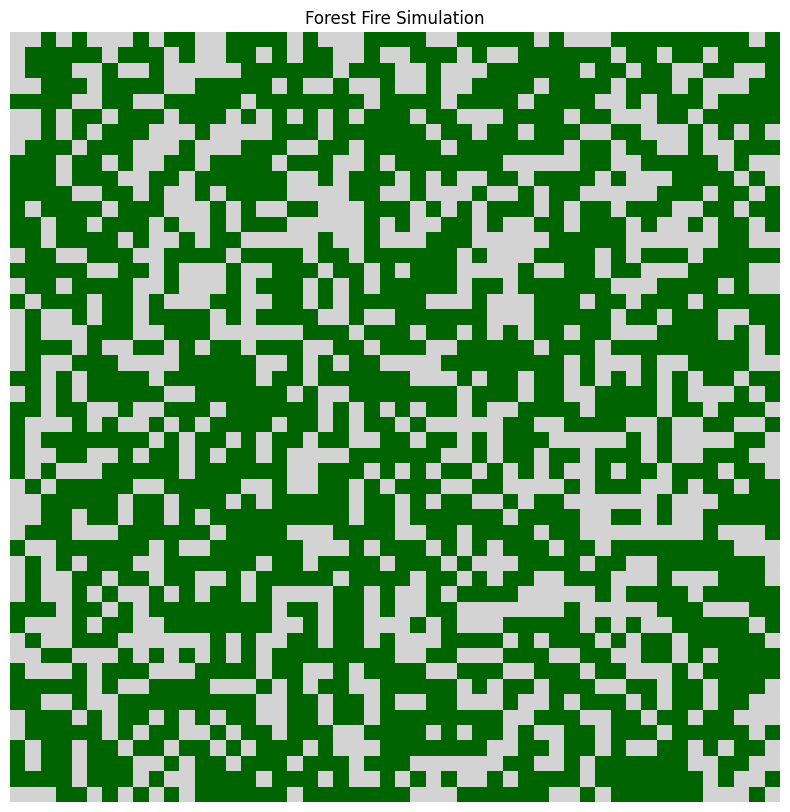

In [56]:
# Create the simulation object
sim = ForestFireSimulation(
    width=50,
    height=50,
    p_growth=0.01,
    p_lightning=0.001
)

sim.run_single_step()

Let's now fast-forward 100 steps into the simulation to see how the forest has changed.

Ouch! The amount of active fires is not that high but we can see that, over time, a lot of damage has been caused to the forest's ecosystem :(

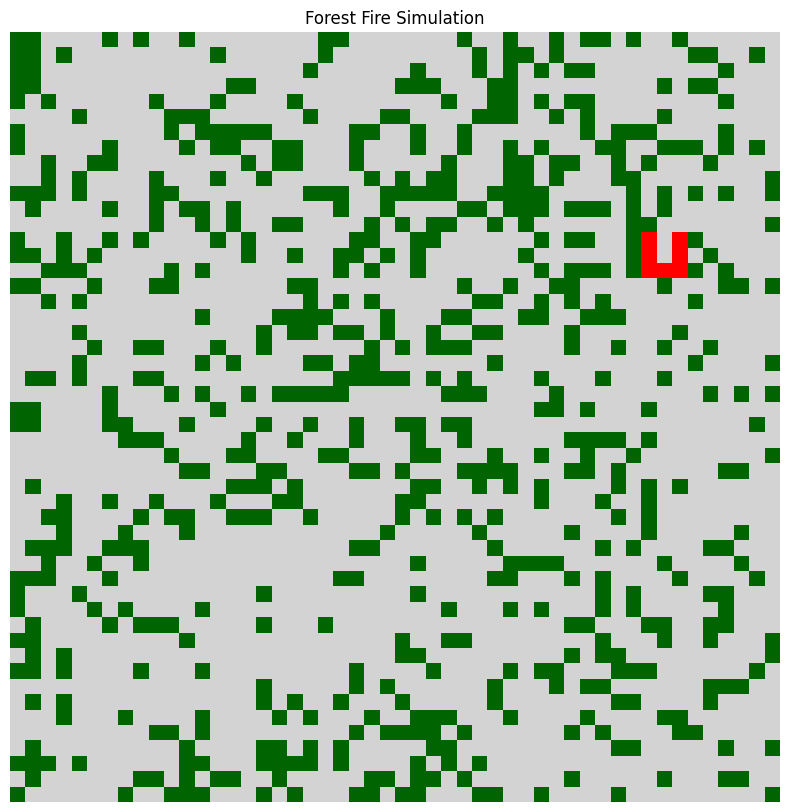

In [57]:
sim.run_multi_step(100)

## Exercise 2

Consider two additional scenarios, rapid_spread and slow_growth. Show the state of each scenario when running the multi step function for 100 steps. In maximum 4 sentences, explain:
  - What do the states at t = 100 for both rapid_spread and slow_growth look like
  - Compare and contrast the forest fire dynamics that both scenarios are modeling
  - What was the joint role played by both p_growth and p_lightning for each scenario?
  - Did either of the simulations result in elimination of any active fires? If so, how?
  - Did either of the simulations result in close to half the board containing active fires? If so, how?

In [ ]:
# The states for the rapid_spread looks completely riddled with both green and red, almost uniformley distributed among the board. The slow_growth looks like
# a fire along the bottom of the border, and a lot less green growth with isolated areas.
# The forest fires for the ladder rapid_spread are alot more devastating. And after the 100 step, a lot more active fires were seen in the rapid_growth.
# No neither of the simualtions resulted in elimination of any active fires.
#the 100step simulation of the rapid_spread resulted in clsoe to half the board containing active fires.


In [59]:
# Different simulation scenarios:

# Rapid spread scenario
rapid_spread = ForestFireSimulation(
    width=50,
    height=50,
    p_growth=0.5,
    p_lightning=0.1
)

# Slow growth scenario
slow_growth = ForestFireSimulation(
    width=50,
    height=50,
    p_growth=0.005,
    p_lightning=0.00001
)

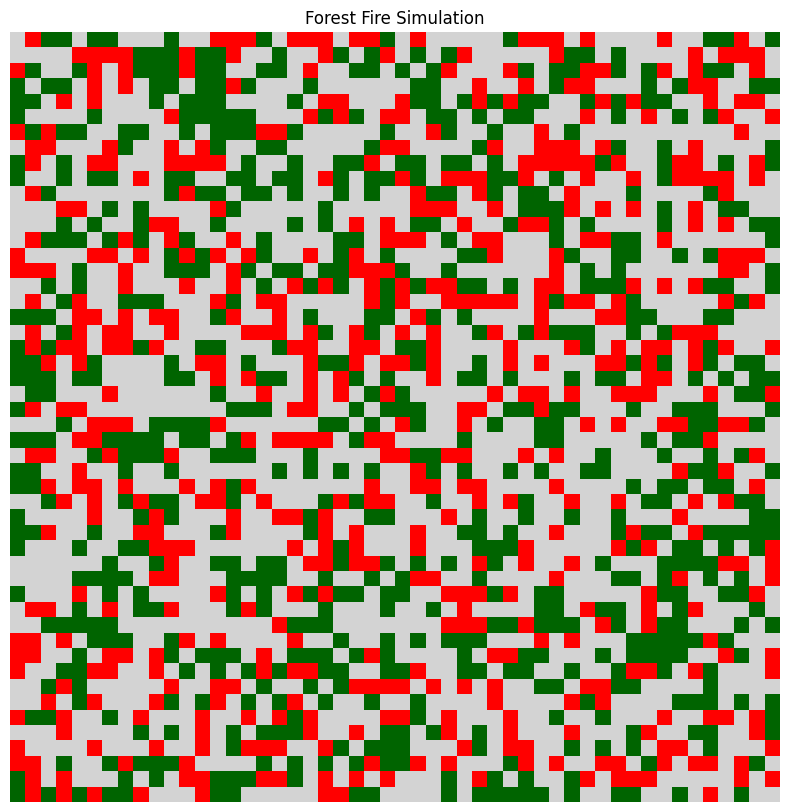

In [60]:
rapid_spread.run_multi_step(100)

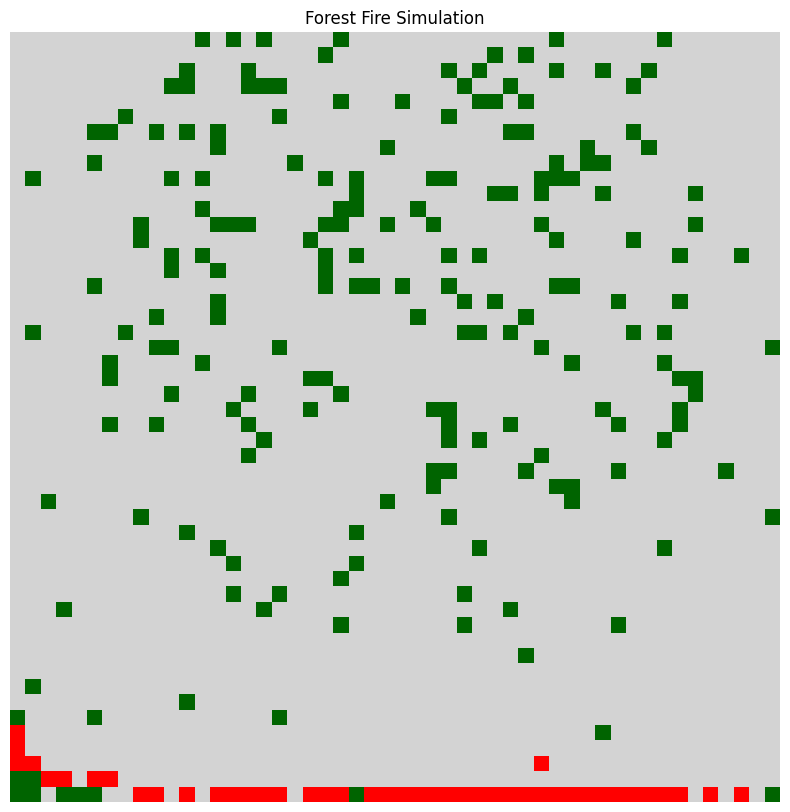

In [61]:
slow_growth.run_multi_step(100)

To model additional behaviors of interest, we could also extend the simulation, e.g.,:
  - Adding wind direction and strength to affect fire spread probability
  - Implementing terrain elevation that influences fire behavior
  - Adding seasonal variations in growth and fire probability
  - Including fire resistance variations among different tree types
  - Implementing fire-fighting interventions
  - Adding moisture levels that affect both growth and fire spread
  - Collecting and analyzing statistics about fire size and frequency
  - Implementing more sophisticated growth patterns based on tree density
  - Adding varying degrees of fire damage instead of complete destruction

As we just saw, simulations such as the forest fire program can be useful tools, with practical applications in:
  - Understanding concepts in complex systems and emergence
  - Demonstrating basic principles of wildfire behavior
  - Exploring how different parameters affect system dynamics
  - Studying the role of randomness in natural systems

Let's reflect more on emergent behavior through John Conway's Game of Life.

## Conway's Game of Life

Conway's Game of Life is deceptively simple. Given an infinite two-dimensional grid of cells, each of which can either be [dead/empty/unpopulated] or [alive/full/populated], the game obeys the following four rules (neighbor means any of the eight surrounding cells):

  - Any live cell with fewer than two live neighbors dies, as if by underpopulation.
  - Any live cell with two or three live neighbors lives on to the next generation.
  - Any live cell with more than three live neighbors dies, as if by overpopulation.
  - Any dead cell with exactly three live neighbors becomes a live cell, as if by reproduction.

These rules are applied to every cell on the board at once; each iteration is one time step. Watch the following video for a few demosntrative examples:https://www.youtube.com/watch?v=ouipbDkwHWA




The primary significance of the "game" is that very simple rules can create systems of breathtaking complexity. The game only has four basic rules, and yet you can create oscillators, glider guns (the first pattern that provably could grow forever), and even ultimately a general purpose computer. Below are a few links that demonstrate these complex behaviors (you should at least go through the first one):
  - Glider gun (hit "Start" to initiate simulation): https://playgameoflife.com/lexicon/Gosper_glider_gun
    - You can explore additional configurations and their behavior through the "Lexicon"
  - Conway's Game of Life simulation that reproduces itself (i.e., simulation within a simulation): https://www.youtube.com/watch?v=xP5-iIeKXE8
  - Building a computer in Conway's Game of Life: https://www.youtube.com/watch?v=Kk2MH9O4pXY
  - Showcase of other dynamics these simple rules can model (ignore the dramatic music...): https://www.youtube.com/watch?v=C2vgICfQawE
  - Origin of the Game of Life as described by John Conway: https://www.youtube.com/watch?v=R9Plq-D1gEk

"Emergence" is the concept that a complex system can arise from small simple interactions. In other words, a bunch of little simple things that interact with each other can result in an enormously complex thing. The collection of things can have properties not present in any of the individual things. The implications are vast.
  - Individual ants behave under simple rules. However, a colony of ants is collectively intelligent and able to solve complex problems.
  - Water molecules are individually quite simple. Who would look at a water molecule and predict that freezing a bunch of them would produce intricate snowflakes?
  - Several types of models, such as LLMs, are the result of many many simple matrix multiplications that collectively find, store, and reproduce complex patterns, which has been offered as an analogy to human conscience resulting from electrical impulses.

Conway's Game of Life is the most obvious illustration of this concept. It's Turing complete and, with just 4 simple rules, provides a model of computation that can compute anything a Turin machine can, meaning it can simulate a computer. There also exist other cellular automata that are computationally universal, meaning they can simulate any computer program.

## Example Applications in Molecular Sciences

Recent research has shown that cellular automata principles can be implemented using DNA molecules, such as DNA Tile Assembly:
- Implementation of binary cellular automata using DNA tiles
- Self-assembling DNA structures that compute logical operations
- Error correction in molecular computing systems

Current research applies cellular automata to understand molecular self-organization, such as protein Folding Dynamics:
- Lattice models of protein folding
- Energy landscape exploration
- Prediction of secondary structures

and membrane Organization:
- Lipid raft formation
- Protein clustering
- Signal transduction pathways

There are also applications related to drug-target interaction prediction:
- Cellular automata models of molecular docking
- Drug resistance evolution
- Hybrid CA-MD models

## Exercise 3

True or False. John Conway's Game of Life Cellular Automaton is capable of simulating any computer program, including a computer itself.

Answer:

In [ ]:
True

# Simulating COVID-19 with Cellular Automata

Modeling the spread of a novel virus and its resulting disease is an important step in learning proper preventive measures. An example of such a simulation for COVID-19 is demonstrated in the following article published in the Washington Post advocating the importance of social distancing: https://www.washingtonpost.com/graphics/2020/world/corona-simulator/

The following simulation studies the effect of different safety policies under epidemiological conditions, such as influence of social distancing and wearing a mask. You should read the implementation details of the simulation described in detail at https://www.washingtonpost.com/graphics/2020/world/corona-simulator/, specifically:
- The Environment
- Movement and Social Distancing
- The Timeline of Infection
- Infection Model and Wearing a Mask
- Safety Policies
- Statistics and Probabilities

Visually, the simulation uses the following representation of cells:
- Color
  - Green is an individual susceptible to infection
  - Red is an individual who is infected
  - Blue is an individual that has recovered
- Shape
  - Squares are non-social distancing individuals
  - Circles are social distancing individuals

You are not expected to understand the implementation details of the following classes to complete the lab exercises. To aid optional understanding  of the implementations, we'll review some details.

The Person class simulates an individual in our epidemic/disease transmission model. The Person class models a person with various characteristics and behaviors related to disease transmission, progression, and social behaviors.

**Basic attributes of the Person:**

- Position in some space
- Age
- Social distancing status (before and during symptoms)
- Mask wearing status (before and during symptoms)
- Movement probability (how likely they are to move around)
- Altruistic behavior (whether they'll take precautions when sick)

**Disease status:**

- Can be susceptible, infected, or recovered
- Tracks how many other people they've infected
- Records information about their behavior during infectious periods (whether they social distanced or wore masks)

**Disease progress:**

The disease progression model has several phases:
- Infection Stages:
  - Latent (infected but not infectious)
  - Infectious (can spread to others)
  - Removal (no longer infectious)
  - Recovery
- Symptom Stages:
  - Incubation (no symptoms yet)
  - Can follow one of four paths:
    * Asymptomatic then recovery
    * Mild symptoms then recovery
    * Mild symptoms, then severe symptoms, then death
    * Mild symptoms, then severe symptoms, then recovery

**Behavior changes:**

- If the person is "altruistic" and develops mild symptoms, they:
  * Reduce their movement
  * Start wearing a mask
  * Begin social distancing
- If they develop severe symptoms:
  * Stop moving around
  * Wear a mask
  * Practice social distancing

**Infection Mechanics:**

- Has a method to determine if a person becomes infected based on:
  * Number of infectious neighbors
  * Base infection probability
  * Whether infected neighbors are wearing masks
  * Uses a Kermack-McKendrick model for calculating infection probability

In [76]:
'''
Notes:
- There are separate probabilities for wearing a mask and social distancing, meaning some people will do both, one or the other
  or neither
- There is an altruistic prob, where people who get mild symptoms have a chance of wearing a mask and social
  distancing (for as long as their symptoms last) if they weren't before.
    - It also says whether someone will intentionally move at a low rate
- People who experience severe symptoms will automatically wear masks and social distance and no longer intentionally move
  but just move defensively
'''
class Person:
    def __init__(self, position, age, social_distance, wear_mask, movement_prob, low_movement_prob, altruistic_prob, infected,
                 total_length_infection, incubation_period_duration_range, infectious_start_before_symptoms_range,
                 infectious_period_duration_range, severe_symptoms_start_range, fatality_occur_range,
                 asymptomatic_prob, severe_prob, fatality_prob):
        self.set_position(position)
        self.age = age
        self.social_distance = social_distance
        self.social_distance_before_symptoms = social_distance
        self.wear_mask = wear_mask
        self.wear_mask_before_symptoms = wear_mask
        self.movement_prob = movement_prob
        self.low_movement_prob = low_movement_prob
        self.movement_prob_before_symptoms = movement_prob
        self.altruistic = np.random.random() < altruistic_prob

        self.susceptible = not infected
        self.infected = infected
        # Most literature says that prob. of reinfection is very low of nonexistent at least in a short period of time
        # But scientists are still not sure
        self.recovered = False
        self.infection_step = -1
        # Keeps track of num of people that this person has infected (or contributed to the infection of)
        self.num_people_infected = 0
        # Also for R0 keep track of number of days during infectious phase they were SD and WM
        self.infectious_days_info = {'SD': 0, 'not SD': 0, 'WM': 0, 'not WM': 0}

        # CREATE INFECTION PERIODS -----
        incubation_period_duration = np.random.randint(incubation_period_duration_range[0],
                                                       incubation_period_duration_range[1] + 1)
        infectious_start_before_symptoms = np.random.randint(infectious_start_before_symptoms_range[0],
                                                             infectious_start_before_symptoms_range[1] + 1)
        infectious_period_duration = np.random.randint(infectious_period_duration_range[0],
                                                       infectious_period_duration_range[1] + 1)
        severe_symptoms_start = np.random.randint(severe_symptoms_start_range[0], severe_symptoms_start_range[1] + 1)
        fatality_occur = np.random.randint(fatality_occur_range[0], fatality_occur_range[1] + 1)

        # Create Infection periods
        infectious_period_start = incubation_period_duration - infectious_start_before_symptoms
        assert infectious_period_start >= 1, \
            '{} is wrong: infectious period start should be greater than 0 because latent period is at least one day'.format(
                infectious_period_start)
        removed_period_start = infectious_period_duration + infectious_period_start
        assert removed_period_start < total_length_infection, \
            '{} is wrong: removal should be less than the total length of infection'.format(removed_period_start)
        # total_length = total_length_infection if removed_period_start < total_length_infection else removed_period_start + 1
        total_length = total_length_infection
        self.infectious_periods = [('latent', 0),
                                   ('infectious', infectious_period_start),
                                   ('remove', removed_period_start),
                                   ('recover', total_length)]

        # Symptoms is more complicated
        self.symptoms_periods = [('incubation', 0)]
        symptoms_start = incubation_period_duration
        assert symptoms_start > infectious_period_start, \
            'Symptoms ({}) start during infectious stage (starts {})'.format(symptoms_start, infectious_period_start)
        assert symptoms_start < removed_period_start, \
            'Symptoms ({}) start during infectious stage (starts {})'.format(symptoms_start, infectious_period_start)
        # 1) Some people are asymptomatic (and have no mild or severe symptoms, and also cant die)
        if np.random.random() < asymptomatic_prob:
            self.symptoms_periods.append(('asymptomatic', symptoms_start))
        # 2) If they arent asymptomatic they start with mild
        else:
            self.symptoms_periods.append(('mild', symptoms_start))
            # 3) Can have severe (or not)
            if np.random.random() < severe_prob:
                severe_start_abs = severe_symptoms_start + symptoms_start
                assert severe_start_abs <= total_length, \
                    'severe symptoms should start ({}) before end of infection'.format(severe_start_abs)
                self.symptoms_periods.append(('severe', severe_start_abs))
                # 4) Can die (or not)
                if np.random.random() < fatality_prob:
                    fatality_start_abs = fatality_occur + severe_symptoms_start + symptoms_start
                    assert fatality_start_abs <= total_length, \
                        'fatality should occur ({}) before end of infection'.format(fatality_start_abs)
                    self.symptoms_periods.append(('death', fatality_start_abs))
        # 5) If didnt die then recover
        if self.symptoms_periods[-1][0] != 'death':
            self.symptoms_periods.append(('recover', total_length))
        # Make sure the symptoms periods is one of 4 diff combinations
        possible_permutations = [['incubation', 'asymptomatic', 'recover'],
                                 ['incubation', 'mild', 'recover'],
                                 ['incubation', 'mild', 'severe', 'death'],
                                 ['incubation', 'mild', 'severe', 'recover']]
        assert [item[0] for item in self.symptoms_periods] in possible_permutations, \
            '{} not a possible symptoms stages permutation'.format(possible_permutations)

        self.current_symptom_stage = None
        self.current_infection_stage = None

    def set_position(self, position):
        self.position = position

    # Not just infected but infectious
    def is_infectious(self):
        return self.current_infection_stage == 'infectious'

    # Progress the infection of an infected person in both infectiousness and symptoms
    def progress_infection(self, data_collector):
        if not self.infected:
            return False, None
        if self.is_infectious():
            if self.social_distance: self.infectious_days_info['SD'] += 1
            else: self.infectious_days_info['not SD'] += 1
            if self.wear_mask: self.infectious_days_info['WM'] += 1
            else: self.infectious_days_info['not WM'] += 1
        self.infection_step += 1
        new_infection_stage = False
        new_symptoms_stage = False
        # If gets to new stage then pop off first
        if self.infection_step == self.infectious_periods[0][1]:
            self.current_infection_stage = self.infectious_periods[0][0]
            self.infectious_periods.pop(0)
            new_infection_stage = True

        if self.infection_step == self.symptoms_periods[0][1]:
            self.current_symptom_stage = self.symptoms_periods[0][0]
            self.symptoms_periods.pop(0)
            new_symptoms_stage = True

        # If dead then return true
        if self.current_symptom_stage == 'death':
            return True, None

        new_SD = None
        # If mild symptoms check altruistic prob to see what happens
        if self.current_symptom_stage == 'mild' and self.altruistic and new_symptoms_stage:
            self.movement_prob = self.low_movement_prob
            self.wear_mask = True
            new_SD = True if not self.social_distance else None
            self.social_distance = True
        elif self.current_symptom_stage == 'severe' and new_symptoms_stage:
            # Severe means SD and WM and NO non-defensive movement
            # todo: Might turn off ALL movement at this stage
            self.movement_prob = 0.
            self.wear_mask = True
            new_SD = True if not self.social_distance else None
            self.social_distance = True

        # If not dead and end of infection then recovered
        if self.current_infection_stage == 'recover' and new_infection_stage:
            self.recovered = True
            self.infected = False
            self.susceptible = False
            self.wear_mask = self.wear_mask_before_symptoms
            new_SD = self.social_distance_before_symptoms if self.social_distance != self.social_distance_before_symptoms else None
            self.social_distance = self.social_distance_before_symptoms
            self.movement_prob = self.movement_prob_before_symptoms
            self.current_symptom_stage = None
            data_collector.add_lifetime_infected(self.num_people_infected, self.infectious_days_info)

        return False, new_SD

    # Check if person is infected given the number of infected (and in infectious phase) people
    # in its immediate neighborhood
    def gets_infected(self, infectious_neighbors, base_infection_prob, mask_infection_prob_decrease, data_collector):
        # Skip if already infected or recovered
        if self.infected or self.recovered or len(infectious_neighbors) == 0:
            return False
        # Use Kermack-McKendrick Model of infection probability
        # 1 - (1 - p) ^ r; p -> infection prob of one person; r -> number of infectious people
        # If an infectious person is wearing a mask then the probability of infecting this susceptible person goes down
        p = [base_infection_prob + (-1. * (neighbor.wear_mask * mask_infection_prob_decrease)) for neighbor in infectious_neighbors]
        p = sum(p) / len(p)
        r = len(infectious_neighbors)
        I_prob = 1 - (1 - p) ** r

        if np.random.random() < I_prob:
            self.infected = True
            self.susceptible = False
            self.current_symptom_stage = self.symptoms_periods[0][0]
            self.current_infection_stage = self.infectious_periods[0][0]
            self.infectious_periods.pop(0)
            self.symptoms_periods.pop(0)
            self.infection_step = 0
            data_collector.increment_total_infected()
            return True
        return False

The DataCollector class is a comprehensive data tracking and visualization system for the epidemic simulation, including:

**Basic data tracking:**
- Tracks key epidemic metrics:
  * Number of Susceptible (S), Infected (I), and Recovered (R) people
  * Number of people Wearing Masks (WM) and Social Distancing (SD)
  * Count of deaths and different symptom severities (mild, severe, asymptomatic)
- Maintains both current values and historical records of these metrics

**Advanced metrics collection:**
- Secondary Attack Rate (SAR): Measures how many susceptible people eventually get infected
- Basic Reproduction Number (R0): Tracks how many people each infected person infects
- R0S: Calculates R0 multiplied by number of susceptible people (important for epidemic dynamics)
- Tracks detailed infection data based on behaviors:
  * People who social distance vs those who don't
  * People who wear masks vs those who don't
  * People who do both or neither

**Data analysis features:**
- Groups infection data into time bins (default 5 time steps)
- Calculates averages for different behavioral groups
- Tracks how different preventive measures (masks, social distancing) affect transmission

**Visualizations:**
- Creates four different plots showing:
  * Infection patterns based on social distancing
  * R0 values for different behavioral groups
  * R0S values for different behavioral groups
- Can print regular updates during simulation
- Allows customization of which metrics to display and how often

**Data storage:**
- Can save all experimental data including:
  * Simulation constants and parameters
  * Visualization plots
  * Detailed CSV files with all metrics
  * Basic and advanced infection data
  * R0 and R0S histories
  * Secondary Attack Rate results

In [77]:
from collections import OrderedDict
import os
from datetime import datetime
import json
import pandas as pd


data_options = ['S', 'I', 'R', 'WM', 'SD', 'death', 'mild', 'severe', 'asymptomatic']

# SAR -> Secondary Attack Rate = total # infected people / total # susceptible (overall metric, ie calculated at end)
# R0 -> Basic Reproductive Number = The number of people an infected person directly infects
# R0S -> R0 x S -> If > 1 then can multiply, = 1 then can become endemic (persistent but tame), < 1 then can die off
advanced_equations = ['SAR', 'R0', 'R0S']


class DataCollector:
    def __init__(self, constants, save_experiment, print_visualizations):
        self.constants = constants
        self.save_experiment = save_experiment
        self.print_visualizations = print_visualizations
        self.basic_to_print = None
        self.adv_to_print = None
        self.frequency_print = 1
        self._reset_data_options(hist=True)
        # Advanced Infection data collection
        # WM, SD, both, neither, total
        self.adv_infection_data = {'total': 0, 'SD': 0, 'not SD': 0}
        self.adv_infection_data_history = OrderedDict({'total': [], 'SD': [], 'not SD': []})
        # For adv equations
        # For SAR (Secondary Attack Rate) need total number of infected overtime
        self.total_infected = 0
        # And need number of S not including initial infected
        self.initial_S = 0
        # For R0 need the current number of each infection lifetime for the current bin
        self.lifetime_infected_bin_size = 5
        self.current_bin_lifetime_infected = []
        # Saves all the bin averages
        self.lifetime_infected_bin_avgs = OrderedDict()
        self.last_bin_avgs = {'total': None, 'SD': None, 'not SD': None, 'WM': None, 'not WM': None, 'both': None, 'neither': None}

    def _reset_data_options(self, hist=False):
        self.current_data = {}
        if hist: self.data_history = OrderedDict()
        for k in data_options:
            self.current_data[k] = 0
            if hist: self.data_history[k] = []

    def set_print_options(self, basic_to_print='all', adv_to_print='all', frequency=1):
        self.basic_to_print = data_options if basic_to_print == 'all' else basic_to_print
        self.adv_to_print = advanced_equations if adv_to_print == 'all' else adv_to_print
        self.frequency_print = frequency

    def increment_total_infected(self):
        self.total_infected += 1

    def increment_initial_S(self):
        self.initial_S += 1

    def _update_adv_infection_data(self, person):
        SD = person.social_distance
        not_SD = not SD
        self.adv_infection_data['total'] += 1
        if SD: self.adv_infection_data['SD'] += 1
        if not_SD: self.adv_infection_data['not SD'] += 1

    def update_data(self, person):
        self.current_data['S'] += person.susceptible
        self.current_data['I'] += person.infected
        if person.infected:
            self._update_adv_infection_data(person)
        self.current_data['R'] += person.recovered
        self.current_data['WM'] += person.wear_mask
        self.current_data['SD'] += person.social_distance
        if person.current_symptom_stage == 'mild':
            self.current_data['mild'] += 1
        elif person.current_symptom_stage == 'severe':
            self.current_data['severe'] += 1
        elif person.current_symptom_stage == 'asymptomatic':
            self.current_data['asymptomatic'] += 1

    def increment_death_data(self, person):
        self.current_data['death'] += 1

    def add_lifetime_infected(self, num_infected, infectious_days_info):
        # Bin infectious_days_info into majority SD, minority SD, majority WM, minority WM (ie did they SD more often then not)
        SD = infectious_days_info['SD'] > infectious_days_info['not SD']
        WM = infectious_days_info['WM'] > infectious_days_info['not WM']
        both = SD and WM
        neither = not SD and not WM
        self.current_bin_lifetime_infected.append({'total': num_infected, 'SD': SD, 'not SD': not SD, 'WM': WM,
                                                   'not WM': not WM, 'both': both, 'neither': neither})

    def reset(self, timestep, last=False):
        # Aggregate history data
        for key, value in list(self.current_data.items()):
            self.data_history[key].append(value)
        for key, value in list(self.adv_infection_data.items()):
            self.adv_infection_data_history[key].append(value)
            self.adv_infection_data[key] = 0
        # If bin is done in lifetime infected get avg and empty bin
        if timestep % self.lifetime_infected_bin_size == 0 and timestep != 0:
            self.lifetime_infected_bin_avgs[timestep] = {}
            # If no one infected recovered/died them move on
            if len(self.current_bin_lifetime_infected) == 0:
                # Set to the last avgs initially and if new ones then set them
                for k, last_avg in list(self.last_bin_avgs.items()):
                    self.lifetime_infected_bin_avgs[timestep][k] = last_avg
            else:
                for k in list(self.last_bin_avgs.keys()):
                    bin_arr = [dic['total'] for dic in self.current_bin_lifetime_infected if dic[k]]
                    if len(bin_arr) == 0:  # No people with that bin type
                        self.lifetime_infected_bin_avgs[timestep][k] = self.last_bin_avgs[k]
                        continue
                    bin_avg = sum(bin_arr) / len(bin_arr)
                    self.lifetime_infected_bin_avgs[timestep][k] = bin_avg
                    self.last_bin_avgs[k] = bin_avg
            self.current_bin_lifetime_infected = []
        # Print
        if timestep % self.frequency_print == 0 and (self.basic_to_print or self.adv_to_print):
            st = 'At timestep: {} --- '.format(timestep)
            if self.basic_to_print:
                for i, val in enumerate(self.basic_to_print):
                    st += '{}: {}'.format(val, self.current_data[val])
                    if i != len(self.basic_to_print)-1:
                        st += ' --- '
            if self.adv_to_print:
                if timestep in self.lifetime_infected_bin_avgs:
                    total_bin_avg = self.lifetime_infected_bin_avgs[timestep]['total']
                    if 'R0' in self.adv_to_print and total_bin_avg != None:
                        st += '\nBasic Reproduction Number (R0): {:.02f}'.format(total_bin_avg)
                    if 'R0S' in self.adv_to_print and total_bin_avg != None:
                        st += '\nR0S: {:.02f} x {} = {:.02f}'.format(total_bin_avg, self.current_data['S'], total_bin_avg * self.current_data['S'])
            print(st)
        # Reset data
        self._reset_data_options()
        # If last print advanced equations
        if last:
            SAR = self.total_infected / self.initial_S
            if 'SAR' in self.adv_to_print:
                print('Secondary Attack Rate (SAR): {} / {} = {:.02f}'.format(self.total_infected, self.initial_S, SAR))
            # Convert the lifetime infected bin avgs to a a dict of lists and a list for the x-vals
            self.R0_hist = {'total': [], 'SD': [], 'WM': [], 'not SD': [], 'not WM': [], 'both': [], 'neither': []}
            self.R0S_hist = {'total': [], 'SD': [], 'WM': [], 'not SD': [], 'not WM': [], 'both': [], 'neither': []}
            self.R0_xvals = []
            for x_val, info in list(self.lifetime_infected_bin_avgs.items()):
                self.R0_xvals.append(x_val)
                S = self.data_history['S'][x_val]
                for k, y_val in list(info.items()):
                    if not y_val: y_val = np.nan
                    R0 = y_val
                    R0S = S * y_val
                    self.R0_hist[k].append(R0)
                    self.R0S_hist[k].append(R0S)
            # Visualizations
            fig, axs = plt.subplots(2, 2, figsize=(15, 10))
            # Infections
            I_xvals = list(range(len(self.adv_infection_data_history['total'])))
            axs[0, 0].plot(I_xvals, self.adv_infection_data_history['total'], 'C0', label='total')
            axs[0, 0].plot(I_xvals, self.adv_infection_data_history['SD'], 'C2', label='SD')
            axs[0, 0].plot(I_xvals, self.adv_infection_data_history['not SD'], 'C3', label='not SD')
            axs[0, 0].set_title('Infections based on SD')
            axs[0, 0].legend(loc="upper left")

            # R0
            R0_xvals = self.R0_xvals
            axs[1, 0].plot(R0_xvals, self.R0_hist['total'], 'C0', label='total')
            axs[1, 0].plot(R0_xvals, self.R0_hist['SD'], 'C2', label='SD')
            axs[1, 0].plot(R0_xvals, self.R0_hist['not SD'], 'C3', label='not SD')
            axs[1, 0].plot(R0_xvals, self.R0_hist['WM'], 'C4', label='WM')
            axs[1, 0].plot(R0_xvals, self.R0_hist['not WM'], 'C1', label='not WM')
            axs[1, 0].plot(R0_xvals, self.R0_hist['both'], 'C5', label='both')
            axs[1, 0].plot(R0_xvals, self.R0_hist['neither'], 'C6', label='neither')
            axs[1, 0].set_title('R0 based on SD and WM')
            axs[1, 0].legend(loc="upper left")

            # Save
            if self.save_experiment:
                # Create new directory (name of current date and time)
                now = datetime.now()
                dt_string = now.strftime("%d-%m-%Y_%H-%M-%S")
                sub_dir = os.path.join('experiments', dt_string)
                new_dir = os.path.join(os.getcwd(), sub_dir)
                os.mkdir(new_dir)
                # Save constants
                constants_file = os.path.join(sub_dir, 'constants.json')
                json.dump(self.constants, open(constants_file, 'w'), indent=4)
                # Save visualizations
                figure_file = os.path.join(sub_dir, 'plots.png')
                plt.savefig(figure_file)
                # Save data as .csv and txt
                # Basic
                basic_data_file = os.path.join(sub_dir, 'basic_data.csv')
                self.data_history['timestep'] = I_xvals
                basic_data_df = pd.DataFrame(data=self.data_history)
                basic_data_df.to_csv(basic_data_file, index=False)
                # Advanced infection
                adv_I_file = os.path.join(sub_dir, 'infection_data.csv')
                self.adv_infection_data_history['timestep'] = I_xvals
                adv_I_df = pd.DataFrame(data=self.adv_infection_data_history)
                adv_I_df.to_csv(adv_I_file, index=False)
                # R0
                R0_file = os.path.join(sub_dir, 'R0_data.csv')
                self.R0_hist['timestep'] = self.R0_xvals
                R0_df = pd.DataFrame(data=self.R0_hist)
                R0_df.to_csv(R0_file, index=False)
                # R0S
                R0S_file = os.path.join(sub_dir, 'R0S_data.csv')
                self.R0S_hist['timestep'] = self.R0_xvals
                R0S_df = pd.DataFrame(data=self.R0S_hist)
                R0S_df.to_csv(R0S_file, index=False)
                # Save SAR to txt file
                SAR_file = os.path.join(sub_dir, 'SAR.txt')
                with open(SAR_file, 'w') as f:
                    f.write(str(SAR))

            if self.print_visualizations:
                plt.show()

The configuration states, rules, and experiments on different configurations are described in the linked article referenced earlier. To set up for our first simulation, do the following:
- Upload the constants.json file from the lab assignments page. Do not place it within a folder. This file is necessary to define the simulation input configuration.
- Create an empty `experiments` folder where results of the simulation will be stored.

Then run the simulation cells, review the results, and complete exercises 4 and 5. Note that the simulation code has been modified to only show two of the subplots.

In [87]:
import random
import pygame
import json
import os

os.makedirs('experiments', exist_ok=True)


# Different color models (only one right now)
color_models = {'SIR': {'susceptible': (204, 255, 204), 'infected': (255, 204, 204), 'recovered': (204, 204, 255)}}
# Different shape models (if you care about SD or WM more)
shape_models = {'SD': {True: 'circle', False: 'rect'},
                'WM': {True: 'circle', False: 'rect'}}
# Policies that define overall safety level of the population
policies_safety = {
    'very high': {'social_distance_prob': 0.75, 'wear_mask_prob': 0.75},
    'high': {'social_distance_prob': 0.5, 'wear_mask_prob': 0.5},
    'medium': {'social_distance_prob': 0.25, 'wear_mask_prob': 0.25},
    'low': {'social_distance_prob': 0.10, 'wear_mask_prob': 0.10},
    'mixed': {'social_distance_prob': 0.10, 'wear_mask_prob': 0.75},
}


class CellularAutomation:
    def __init__(self, constants, data_collect):
        self.grid_C = constants['grid']
        self.render_C = constants['render']
        self.person_C = constants['person']
        self.disease_C = constants['disease']
        self.data_collect = data_collect
        # Need two sets of ids (correspond uniquely to a person)
        # 1) Those who practice social distancing
        # 2) Those who do not practice social distancing
        self.ids_social_distance = set()
        self.ids_not_social_distance = set()
        # The person objects
        # id (int): person (object)
        self.id_person = {}
        # Grid stores the person IDs in a 2D structure
        self.grid = np.empty(shape=(self.grid_C['height'], self.grid_C['width']), dtype=object)
        self.next_id = 0
        # The currently open positions (no person on it)
        self.open_positions = []
        for y in range(self.grid_C['height']):
            for x in range(self.grid_C['width']):
                self.open_positions.append((x, y))
        # Initialize the grid
        self._initialize_grid()

    # Out of bounds
    def _oob(self, x, y):
        return x < 0 or y < 0 or x >= self.grid_C['width'] or y >= self.grid_C['height']

    # Env wraps - so get correct pos
    def _get_cell_pos(self, x, y):
        def corrected(val, max_val):
            if val < 0:
                 return max_val + val
            elif val >= max_val:
                return max_val - val
            else:
                return val
        corrected_x = corrected(x, self.grid_C['width'])
        corrected_y = corrected(y, self.grid_C['height'])
        return corrected_x, corrected_y

    # Is the cell empty
    def _is_empty(self, x=None, y=None, position=None):
        if x and y:
            return self.grid[y, x] is None
        return self.grid[position[1], position[0]] is None

    # A person can die from the disease
    def _kill_person(self, id, social_distance):
        person = self.id_person[id]
        if social_distance: self.ids_social_distance.remove(id)
        else: self.ids_not_social_distance.remove(id)
        position = person.position
        self._clear_cell(position)
        assert person.infected
        self.data_collect.increment_death_data(person)
        # todo: Not sure if I should keep this because if someone dies early then they dont really get a full infectious lifetime
        # self.data_collect.add_lifetime_infected(person.num_people_infected, person.infectious_days_info)
        del self.id_person[id]

    def _clear_cell(self, position):
        self.grid[position[1], position[0]] = None
        self.open_positions.append(position)

    def _add_to_cell(self, id, position):
        assert self._is_empty(position=position)
        self.id_person[id].position = position
        self.grid[position[1], position[0]] = id
        self.open_positions.remove(position)

    def _move_person(self, id, person, new_position):
        current_position = person.position
        # Clear current position
        self._clear_cell(current_position)
        # Place person in new cell
        self._add_to_cell(id, new_position)
        person.set_position(new_position)

    # Grid initialization ------
    def _create_person(self, position):
        assert self._is_empty(position=position)
        age = np.random.randint(self.person_C['age_range'][0], self.person_C['age_range'][1]+1)
        policy = policies_safety[self.person_C['policy_type']]
        SD_prob = policy['social_distance_prob']
        SD = True if np.random.random() < SD_prob else False
        WM_prob = policy['wear_mask_prob']
        WM = True if np.random.random() < WM_prob else False
        infected = np.random.random() < self.person_C['initial_infection_prob']

        if not infected: self.data_collect.increment_initial_S()

        person = Person(position, age, SD, WM, self.person_C['movement_prob'], self.person_C['altruistic_movement_prob'],
                        self.person_C['altruistic_prob'], infected,
                        self.disease_C['total_length_infection'], self.disease_C['incubation_period_duration_range'],
                        self.disease_C['infectious_start_before_symptoms_range'],
                        self.disease_C['infectious_period_duration_range'],
                        self.disease_C['severe_symptoms_start_range'],
                        self.disease_C['death_occurrence_range'], self.disease_C['asymptomatic_prob'],
                        self.disease_C['severity_prob'], self.disease_C['death_prob'])

        self.id_person[self.next_id] = person
        data_collect.update_data(person)
        if SD: self.ids_social_distance.add(self.next_id)
        else: self.ids_not_social_distance.add(self.next_id)
        self._add_to_cell(self.next_id, position)
        self.next_id += 1

    # Create all the people
    def _initialize_grid(self):
        for p in range(self.grid_C['initial_pop_size']):
            # Select random position
            position = random.choice(self.open_positions)
            # Create person
            self._create_person(position)

    # Yield neighbors
    # Return Neighbor (or None), neighbor_position absolute and relative
    def _yield_neighbors(self, position, side_length):
        x, y = position[0], position[1]
        for i in range(side_length ** 2):
            cluster_mid = side_length // 2
            rel_x = (i % side_length) - cluster_mid
            rel_y = (i // side_length) - cluster_mid
            abs_x = x + rel_x
            abs_y = y + rel_y
            correct_x, correct_y = self._get_cell_pos(abs_x, abs_y)
            located_id = self.grid[correct_y, correct_x]  # Might be None if no person there
            if located_id == None:
                yield None, (correct_x, correct_y), (rel_x, rel_y)
            else:
                yield self.id_person[located_id], (correct_x, correct_y), (rel_x, rel_y)

    # This decides movement and num of infected neighbors FOR SD people
    def _check_neighbors_SD(self, id, person):
        def check_neighbors(last_position=None):
            safe_cells = {(-1, -1): None, (0, -1): None, (1, -1): None, (-1, 0): None, (1, 0): None, (-1, 1): None, (0, 1): None, (1, 1): None}
            infected_neighbors = []
            for neighbor, neighbor_pos, neighbor_pos_rel in self._yield_neighbors(person.position, 3):
                if neighbor_pos == person.position:
                    continue
                # Get abs pos
                safe_cells[neighbor_pos_rel] = neighbor_pos
                # Add to infected if infectious neighbor
                if neighbor and neighbor.is_infectious():
                    infected_neighbors.append(neighbor)
                # Remove from safe cell if cell contains a person or it was the last pos
                if neighbor or last_position == neighbor_pos:
                    del safe_cells[neighbor_pos_rel]
            return infected_neighbors, safe_cells
        # First get number of infected around this and check if it gets infected
        infected_neighbors, safe_cells = check_neighbors()
        # Check if infected
        self._check_infection(person, infected_neighbors)
        # Then Moving
        # Move it if its own cell is not safe OR its moving intenionally
        move_length_SD = 1 if len(safe_cells) < 8 else self.person_C['move_length']  # Move only one time if just moving cuz its unsafe
        if len(safe_cells) < 8 or np.random.random() < person.movement_prob:
            for m in range(move_length_SD):
                last_position = person.position
                did_move = False
                # Shuffle the safe positions and choose the first actually safe one by checking a 3x3 around it (not including the person.position)
                for safe_cell_rel_pos in random.sample(list(safe_cells.keys()), len(list(safe_cells.keys()))):
                    safe_cell_abs_pos = safe_cells[safe_cell_rel_pos]
                    # Check if its safe (dont check the person.position)
                    safe = True
                    for neighbor, neighbor_pos, _ in self._yield_neighbors(safe_cell_abs_pos, 3):
                        if neighbor_pos == person.position:
                            continue
                        if neighbor:
                            safe = False
                            break
                    # First one that is safe: move there
                    if safe:
                        self._move_person(id, person, safe_cell_abs_pos)
                        infected_neighbors, safe_cells = check_neighbors(last_position)
                        self._check_infection(person, infected_neighbors)
                        did_move = True
                        break
                # End if it did not move
                if not did_move:
                    break

    # If not SD then move if moving intentionally
    def _check_neighbors_not_SD(self, id, person):
        def check_neighbors(last_position=None):
            empty_spots = []
            infected_neighbors = []
            for neighbor, neighbor_pos, _ in self._yield_neighbors(person.position, 3):
                if neighbor_pos == person.position:
                    continue
                # Add to infected if infectious neighbor
                if neighbor and neighbor.is_infectious():
                    infected_neighbors.append(neighbor)
                # Add empty spot (also if not the last position the person was at if moving more than once)
                if not neighbor and neighbor_pos != last_position:
                    empty_spots.append(neighbor_pos)
            return infected_neighbors, empty_spots
        # First get number of infected around this and check if it gets infected
        infected_neighbors, empty_spots = check_neighbors()
        # Check if infected
        self._check_infection(person, infected_neighbors)
        # Then Moving
        if np.random.random() < person.movement_prob:
            for m in range(self.person_C['move_length']):
                # if somewhere to move
                if len(empty_spots) > 0:
                    new_spot = random.choice(empty_spots)
                    last_position = person.position
                    self._move_person(id, person, new_spot)
                    infected_neighbors, empty_spots = check_neighbors(last_position)
                    self._check_infection(person, infected_neighbors)
                else:
                    break

    def _check_infection(self, person, infected_neighbors):
        newly_infected = person.gets_infected(infected_neighbors, self.disease_C['base_infection_prob'],
                                              self.disease_C['mask_infection_prob_decrease'],
                                              self.data_collect)
        # If this person was just infected then add to the num of people infected to each neighbor for calc. Ro
        if newly_infected:
            for person in infected_neighbors:
                person.num_people_infected += 1

    def _update_person(self, id):
        person = self.id_person[id]
        # Progress Infection (if infected)
        dead, new_SD = person.progress_infection(self.data_collect)
        if dead:
            self._kill_person(id, person.social_distance)
            return None # Continue to next person
        # At the start figure out where the person is going to move AND the number of infected persons around them
        self._check_neighbors_SD(id, person) if person.social_distance else self._check_neighbors_not_SD(id, person)
        return new_SD

    # For rendering
    def _get_person_color(self, person):
        if self.render_C['color_model'] == 'SIR':
            colors = color_models['SIR']
            if person.susceptible: return colors['susceptible']
            if person.infected: return colors['infected']
            return colors['recovered']

    def _render(self, id, screen):
        person = self.id_person[id]
        shape_model = self.render_C['shape_model']
        if shape_model == 'SD':
            shape = shape_models[shape_model][person.social_distance]
        else:
            shape = shape_models[shape_model][person.wear_mask]
        color = self._get_person_color(person)
        cell_size = self.render_C['cell_size']
        if shape == 'rect':
            pygame.draw.rect(screen, color,
                             [person.position[0] * cell_size, person.position[1] * cell_size, cell_size, cell_size])
        else:
            radius = cell_size // 2
            center_x = (person.position[0] * cell_size) + radius
            center_y = (person.position[1] * cell_size) + radius
            pygame.draw.circle(screen, color, (center_x, center_y), radius)

    def run(self, render=False):
        if render:
            # Initialize the game engine
            pygame.init()
            # Set the height and width and title of the screen
            screen_width = self.render_C['cell_size'] * self.grid_C['width']
            screen_height = self.render_C['cell_size'] * self.grid_C['height']
            screen = pygame.display.set_mode((screen_width, screen_height))
            pygame.display.set_caption("Population Dynamics")
            clock = pygame.time.Clock()
            # Initially set the screen to all black
            screen.fill((0, 0, 0))
        for t in range(self.grid_C['number_iterations']):
            self.data_collect.reset(t)
            def loop_through_ids(ids):
                # Keep track of any switches between SD lists
                new_SD_list = []
                new_not_SD_list = []
                # Shuffle - Random order
                lis = list(ids)
                random.shuffle(lis)
                for id in lis:
                    new_SD = self._update_person(id)
                    # If dead then continue
                    if id not in self.id_person: continue
                    if new_SD is True: new_SD_list.append(id)
                    elif new_SD is False: new_not_SD_list.append(id)
                    # Update data collection
                    self.data_collect.update_data(self.id_person[id])
                    # Render
                    if render: self._render(id, screen)
                return new_SD_list, new_not_SD_list
            # Update (in random order) those who do NOT practice social distancing
            new_SD, new_not_SD_list = loop_through_ids(self.ids_not_social_distance)
            assert len(new_not_SD_list) == 0
            # Next update (in random order) those who DO practice social distancing, so they get to be at a safe dist.
            # from others at the end of the iteration
            new_SD_list, new_not_SD = loop_through_ids(self.ids_social_distance)
            assert len(new_SD_list) == 0
            # Switch people
            for id in new_SD:
                self.ids_not_social_distance.remove(id)
                self.ids_social_distance.add(id)
            for id in new_not_SD:
                self.ids_social_distance.remove(id)
                self.ids_not_social_distance.add(id)
            if render:
                pygame.display.flip()
                screen.fill((0, 0, 0))
                # Frames per second
                if self.render_C['fps']: clock.tick(self.render_C['fps'])
        self.data_collect.reset(t+1, last=True)

In [84]:
constants = json.load(open('constants.json'))

In [85]:
# Can save a run as an experiment which saves the data, visualizations and constants in a experiments directory
data_collect = DataCollector(constants, save_experiment=True, print_visualizations=True)


In [86]:
# Can print data (look at `data_options` at top of `data_collector.py` for options) and how often to print
data_collect.set_print_options(basic_to_print=['S', 'I', 'R', 'death'], frequency=1)
CA = CellularAutomation(constants, data_collect)


At timestep: 0 --- S: 0 --- I: 0 --- R: 0 --- death: 0
At timestep: 1 --- S: 233 --- I: 36 --- R: 223 --- death: 0
At timestep: 2 --- S: 229 --- I: 38 --- R: 225 --- death: 0
At timestep: 3 --- S: 226 --- I: 40 --- R: 226 --- death: 0
At timestep: 4 --- S: 226 --- I: 35 --- R: 231 --- death: 0
At timestep: 5 --- S: 224 --- I: 34 --- R: 234 --- death: 0
Basic Reproduction Number (R0): 1.12
R0S: 1.12 x 224 = 252.00
At timestep: 6 --- S: 224 --- I: 31 --- R: 237 --- death: 0
At timestep: 7 --- S: 222 --- I: 30 --- R: 240 --- death: 0
At timestep: 8 --- S: 222 --- I: 25 --- R: 244 --- death: 1
At timestep: 9 --- S: 221 --- I: 24 --- R: 246 --- death: 0
At timestep: 10 --- S: 218 --- I: 26 --- R: 247 --- death: 0
Basic Reproduction Number (R0): 2.29
R0S: 2.29 x 218 = 498.29
At timestep: 11 --- S: 218 --- I: 26 --- R: 247 --- death: 0
At timestep: 12 --- S: 217 --- I: 24 --- R: 250 --- death: 0
At timestep: 13 --- S: 215 --- I: 22 --- R: 254 --- death: 0
At timestep: 14 --- S: 215 --- I: 19 

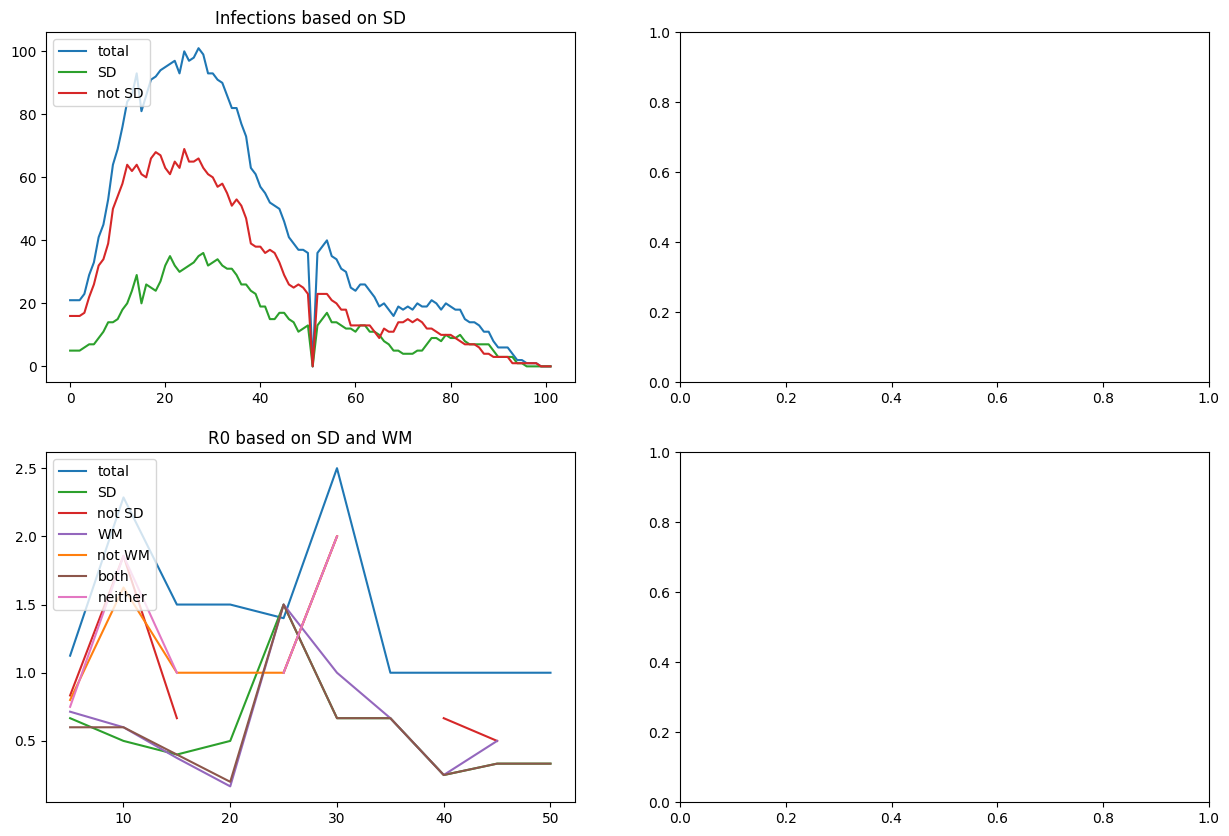

In [83]:
# Can render each timestep with pygame
CA.run(render=True)


## Exercise 4

Describe the results of the simulation run, which uses policy type medium safety as discussed in the referenced Medium article. You should write at least one paragraph.

In [ ]:

# Number of Susceptible (S), Infected (I), and Recovered (R) people
# Number of people Wearing Masks (WM) and Social Distancing (SD)
# Count of deaths and different symptom severities (mild, severe, asymptomatic)

# Secondary Attack Rate (SAR): Measures how many susceptible people eventually get infected
# Basic Reproduction Number (R0): Tracks how many people each infected person infects
# R0S: Calculates R0 multiplied by number of susceptible people (important for epidemic dynamics)
# Tracks detailed infection data based on behaviors:
# People who social distance vs those who don't
# People who wear masks vs those who don't
# People who do both or neither

# Infections based on social distancing so a large increase/ maybe evens its peak around 10-30(units of x axis) irregardless of whether they were wearing a mask or not suggesting the severity of the
# virus had the maximum effect during this period. People who were not social distancing saw the impact the infection had on them, as the number of infections climbed higher compared to the
# individuals who were not social distancing. RO based on SD and WM were definitely different in that individuals who were wearing the mask as well as social distaning created the upper and lower bounds
# where the average of the two was a tight fit between the two in indviduals who did both SD and WM. Overall, the results suggest that social distancing reduced infection levels,
# but the medium-safety policy was not strong enough to prevent a substantial outbreak.

## Exercise 5

To the earlier CellularAutomation class implementation, we added a definition for a Mixed Safety Policy where:
- Each person initially has a 5% chance of social distancing
- Each person initially has a 80% chance of wearing a mask

Modify constants.json to use the mixed safety policy. A description of each entry in constants.json is below, and you will only need to modify one line in the constants.json file that you uploaded earlier.

Reference:
```
{
  "grid": {
    "width": "Width in cells of grid",
    "height": "Height in cells of grid",
    "initial_pop_size": "Number of people initially spawned in grid",
    "number_iterations": "Number of total iterations of simulation"
  },
  "render": {
    "cell_size": "Cell width/height in pixels",
    "color_model": "How to color people",
    "shape_model": "How to shape people",
    "fps": "How fast in frames-per-second to run the simulation ('None' for as-fast-as-possible)"
  },
  "person": {
    "age_range": "The range for selecting someone's age",
    "movement_prob": "Defines the probability of a person moving each iteration",
    "altruistic_movement_prob": "The movement probability of someone who is altruistic (defined below)",
    "move_length": "Number of steps a person can take if they decide to move",
    "initial_infection_prob": "The probability of infection when initially spawning people",
    "altruistic_prob": "Probability of being altruistic and therefore social distancing and wearing a mask when symptoms arise",
    "policy_type": "Picks one of the predefined policies in 'main.py' which defines initial spawn probabilities for social distancing, wearing a mask and not moving around too much"
  },
  "disease": {
    "base_infection_prob": "The base infection probability of one infectious person",
    "mask_infection_prob_decrease": "The decrease in 'base_infection_prob' if the infectious person is wearing a mask",
    "total_length_infection": "Total length in days (usually) of the infection in a person (REF 3)",
    "incubation_period_duration_range": "Range of possible number of incubation days (REF 3)",
    "infectious_period_duration_range": "Range of possible number of infectious days (REF 3)",
    "infectious_start_before_symptoms_range": "Range of possible number of days the infectious stage starts before symptoms start (REF 3)",
    "severity_prob": "The probability of severe symptoms (given not asymptomatic) (REF 8)",
    "severe_symptoms_start_range": "The range of possible number of days that severe symptoms begin after mild symptoms starting",
    "death_prob": "The probability of death occurring (given severe symptoms, hence why its high-ish) (REF 8)",
    "death_occurrence_range": "The range of possible number of days that death occurs after severe symptoms begin",
    "asymptomatic_prob": "The probability of being asymptomatic (no symptoms but still infectious) (REF 1)"
  }
}
```

Run the simulation with the Mixed Safety Policy configured and show the plots. Describe and justify what you believe are the important findings (at least two) from this simulation, along with at least one result that you expected and at least one result that surprised you. Also provide the updated line in constants.json where you made the change to the file.

In [ ]:
# "policy_type": "mixed" was changed in the file
# An important finding from this graph is that  the risk factor for infection went through the roof when neither SD or WM was implemented. Synonymous with the findings
# when the most infections occured. Overall the results were based on who practiced social distancing and wearing masks. The most infections seemed to happen
# when individuals did not commit to either of those scenarios. Honestly, except for the sporadic R/O lines nothing here suprised me. Without proper prevention, risk of infection is expected
# to go up.
#
# To add to this their is sporadic data, with lines all over the place in the second graph of R/O, i expected mixed results but these results are so sporadic and a commotion to decipher.